
# Week 9 — Gradient Boost: Learning Rate, Estimators, Depth, Regularization

**Course:** Data Science Capstone (Module C)  
**Week:** 9  
**Author:** Tetiana Kravchuk

**Date:** 2025-11-02

This notebook applies **Gradient Boosting** to the Capstone dataset. It follows the Week 9 goals:

- Explain how gradient boost works (sequential weak learners fit to residuals).
- Construct a gradient-boosting model.
- Compare the impact of different **learning rates** and **n_estimators**.
- Evaluate how **tree depth** and **regularization** affect under/overfitting.
- Document metrics, tuning, and overfitting controls for **Milestone Two**.




## 0. Setup

In [1]:

# Core
import os
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve, validation_curve
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Models
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

# Viz
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.set_printoptions(suppress=True)
pd.set_option('display.max_columns', 100)


## 1) Project Brief (for Milestone Two)
**Dataset:** Zillow Single Family Residence properties (cleaned), ~{fill row count from df.shape}, Massachusetts subset from prior weeks  
**Target:** `taxvaluedollarcnt` (continuous, tax-assessed total property value)  
**Goal/Question:** Predict assessed home value from property + location features to understand key value drivers and build a baseline pricing model.  
**Key Features:** Lot size, living area (`calculatedfinishedsquarefeet`), beds/baths, year built, latitude/longitude (or zipcode), property use type, quality/condition flags.  
**Train/Test Split Strategy:** 80/20 random split (fixed seed=42). Stratification not used (regression).  

## 2) Load Data

In [2]:

CSV_PATH = "zillow_cleaned.csv" 

assert os.path.exists(CSV_PATH), f"File not found: {CSV_PATH}. Please set CSV_PATH."

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
df.head()


Shape: (64894, 19)


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,7.0,33634931.0,-117869207.0,4506.0,261.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,4.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,10.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


## 3) Quick EDA (Shapes, Nulls, Types)

In [3]:

display(df.describe(include='all').transpose().head(20))
display(df.dtypes.head(30))
nulls = df.isna().mean().sort_values(ascending=False)
print("Columns with missing values (top 20):")
display(nulls.head(20))


,count,mean,std,min,25%,50%,75%,max
bathroomcnt,64894.0,2.267020e+00,0.908387,0.0,2.000000e+00,2.0,3.000000e+00,10.0
bedroomcnt,64894.0,3.082103e+00,0.993875,0.0,2.000000e+00,3.0,4.000000e+00,11.0
buildingqualitytypeid,64894.0,6.579838e+00,1.656900,1.0,6.000000e+00,6.0,8.000000e+00,12.0
calculatedbathnbr,64894.0,2.271042e+00,0.904316,1.0,2.000000e+00,2.0,3.000000e+00,10.0
calculatedfinishedsquarefeet,64894.0,1.767196e+03,826.104685,128.0,1.200000e+03,1555.0,2.122000e+03,5954.0
finishedsquarefeet12,64894.0,1.767196e+03,826.104685,128.0,1.200000e+03,1555.0,2.122000e+03,5954.0
fips,64894.0,6.047658e+03,20.657731,6037.0,6.037000e+03,6037.0,6.059000e+03,6111.0
fullbathcnt,64894.0,2.216707e+00,0.886023,1.0,2.000000e+00,2.0,3.000000e+00,10.0
heatingorsystemtypeid,64894.0,3.531729e+00,2.373628,1.0,2.000000e+00,2.0,7.000000e+00,24.0
latitude,64894.0,3.403452e+07,260889.483042,33339527.0,3.384373e+07,34046408.0,3.418635e+07,34818767.0


bathroomcnt                     float64
bedroomcnt                      float64
buildingqualitytypeid           float64
calculatedbathnbr               float64
calculatedfinishedsquarefeet    float64
finishedsquarefeet12            float64
fips                            float64
fullbathcnt                     float64
heatingorsystemtypeid           float64
latitude                        float64
longitude                       float64
lotsizesquarefeet               float64
propertylandusetypeid           float64
regionidcounty                  float64
regionidzip                     float64
roomcnt                         float64
unitcnt                         float64
yearbuilt                       float64
taxvaluedollarcnt               float64
dtype: object

Columns with missing values (top 20):


bathroomcnt                     0.0
longitude                       0.0
yearbuilt                       0.0
unitcnt                         0.0
roomcnt                         0.0
regionidzip                     0.0
regionidcounty                  0.0
propertylandusetypeid           0.0
lotsizesquarefeet               0.0
latitude                        0.0
bedroomcnt                      0.0
heatingorsystemtypeid           0.0
fullbathcnt                     0.0
fips                            0.0
finishedsquarefeet12            0.0
calculatedfinishedsquarefeet    0.0
calculatedbathnbr               0.0
buildingqualitytypeid           0.0
taxvaluedollarcnt               0.0
dtype: float64

## 4) Select Target and Features

In [ ]:
# === Set your target column ===
TARGET = "taxvaluedollarcnt"

assert TARGET in df.columns, f"Target '{TARGET}' not in columns."

# Drop rows where target missing
df_model = df.dropna(subset=[TARGET]).copy()

# Known/suspected leakage or identifiers (only drop those that exist)
LEAKAGE_COLS = [
    "parcelid",            # unique ID
    "transactiondate",     # post-outcome timing info (if present)
    "taxamount",           # tightly correlated with target
    "assessmentyear",      # future-year value info
    "propertyzoningdesc"   # may leak zoning bias
]

# Drop target and existing leakage columns
X = df_model.drop(columns=[TARGET] + [c for c in LEAKAGE_COLS if c in df_model.columns])
y = df_model[TARGET]

print("X shape:", X.shape, "| y shape:", y.shape)

# Determine task type
task = "regression" if np.issubdtype(y.dtype, np.number) and y.nunique() > 10 else "classification"
print("Detected task:", task)

X shape: (64894, 18) | y shape: (64894,)
Detected task: regression


## 5) Train / Test Split

In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y if task=='classification' else None
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (51915, 18) Test: (12979, 18)


## 6) Preprocessing Pipeline

In [ ]:


numeric_selector = selector(dtype_include=np.number)
categorical_selector = selector(dtype_exclude=np.number)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Make OneHotEncoder dense (HistGradientBoosting requires dense arrays)
try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # sklearn >=1.2
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))         # older sklearn
    ])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_selector),
    ("cat", categorical_transformer, categorical_selector)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x1770689e0>),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x177069c10>)])

## 7) Baseline Gradient Boosting Model

In [ ]:

if task == "regression":
    base_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
else:
    base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", base_model)
])

# Fit baseline
pipe.fit(X_train, y_train)

# Evaluate baseline
if task == "regression":
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)   # manual RMSE for broad sklearn support
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[Baseline] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[Baseline] Accuracy: {acc:.4f}")
    if hasattr(pipe, "predict_proba"):
        try:
            y_prob = pipe.predict_proba(X_test)
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                auc = roc_auc_score(y_test, y_prob[:, 1])
                print(f"[Baseline] ROC AUC: {auc:.4f}")
        except Exception as e:
            print("AUC not available:", e)

[Baseline] R2: 0.5544 | RMSE: 279404.1058 | MAE: 183237.0605


## 8) Hyperparameter Tuning: Learning Rate, Estimators, Depth, Regularization

In [ ]:

from sklearn.experimental import enable_hist_gradient_boosting  # no-op in newer sklearn
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform, randint
import numpy as np

if task == "regression":
    model = HistGradientBoostingRegressor(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    scoring = "r2"
else:
    model = HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    scoring = "accuracy"

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

# Narrow, randomized space (fast)
param_dist = {
    "model__learning_rate": loguniform(1e-3, 2e-1),
    "model__max_depth": randint(2, 8),          # depth 2..7
    "model__max_leaf_nodes": randint(15, 63),   # small trees
    "model__max_bins": randint(64, 255),        # histogram bins
    "model__l2_regularization": loguniform(1e-4, 1e1),
    "model__min_samples_leaf": randint(10, 200),
    "model__loss": ["squared_error"] if task=="regression" else ["log_loss"]
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,                 # ≈30 fits × 3 folds = 90 fits total
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

rnd.fit(X_train, y_train)
print("Best Params:", rnd.best_params_)
print("Best CV Score:", rnd.best_score_)

best_pipe = rnd.best_estimator_

# Evaluate
y_pred = best_pipe.predict(X_test)
if task == "regression":
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # no 'squared' arg
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[HGB Tuned] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    acc = accuracy_score(y_test, y_pred)
    print(f"[HGB Tuned] Accuracy: {acc:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Best Params: {'model__l2_regularization': 0.0074593432857265485, 'model__learning_rate': 0.1540359659501924, 'model__loss': 'squared_error', 'model__max_bins': 170, 'model__max_depth': 6, 'model__max_leaf_nodes': 35, 'model__min_samples_leaf': 112}
Best CV Score: 0.5869326484148542
[HGB Tuned] R2: 0.5745 | RMSE: 273013.0705 | MAE: 178564.3784


## 9) Validation Curves (Learning Rate & Estimators)

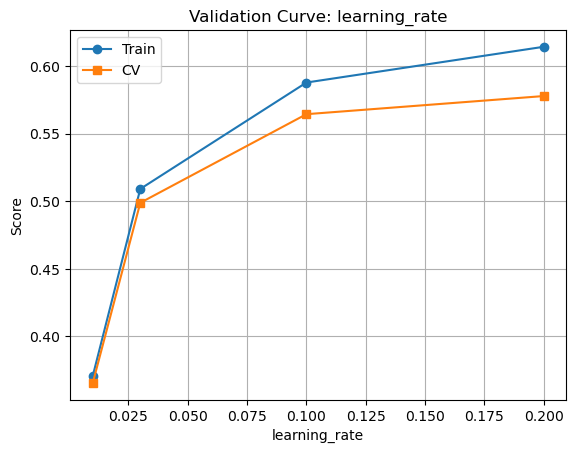

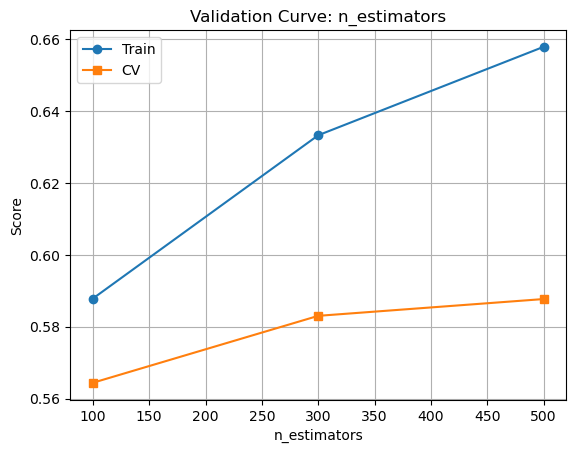

In [9]:

def plot_validation_curve(param_name, param_range):
    est = GradientBoostingRegressor(random_state=RANDOM_STATE) if task=="regression" else GradientBoostingClassifier(random_state=RANDOM_STATE)
    pipe_v = Pipeline([("preprocessor", preprocessor), ("model", est)])
    train_scores, test_scores = validation_curve(
        pipe_v, X_train, y_train,
        param_name=f"model__{param_name}",
        param_range=param_range,
        cv=3,
        scoring=("r2" if task=="regression" else "accuracy"),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(param_range, train_mean, marker="o", label="Train")
    plt.plot(param_range, test_mean, marker="s", label="CV")
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.title(f"Validation Curve: {param_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_validation_curve("learning_rate", [0.01, 0.03, 0.1, 0.2])
plot_validation_curve("n_estimators", [100, 300, 500])


## 10) Learning Curve (Bias/Variance Signal)

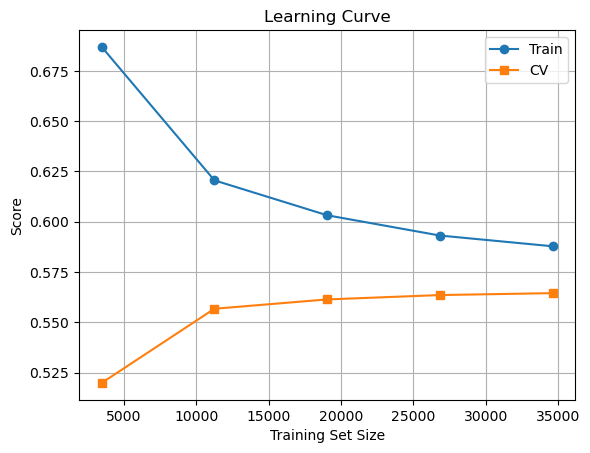

In [ ]:


est = GradientBoostingRegressor(random_state=RANDOM_STATE) if task=="regression" else GradientBoostingClassifier(random_state=RANDOM_STATE)
pipe_lc = Pipeline([("preprocessor", preprocessor), ("model", est)])

train_sizes, train_scores, test_scores = learning_curve(
    pipe_lc, X_train, y_train,
    cv=3,
    scoring=("r2" if task=="regression" else "accuracy"),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,                # makes splits reproducible with random_state
    random_state=RANDOM_STATE    # some sklearn versions ignore; safe to include with shuffle
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), marker="s", label="CV")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

## 11) Feature Importance (Top 20)

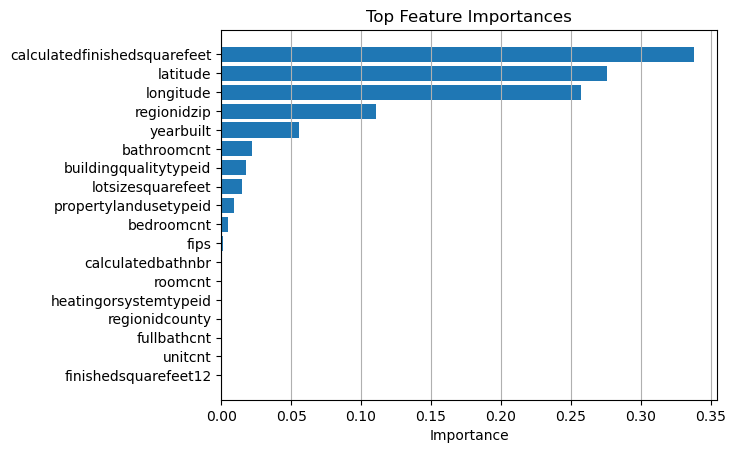

[Model] R2: 0.5745 | RMSE: 273013.0705 | MAE: 178564.3784


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

# 0) Required globals or sensible defaults
RANDOM_STATE = globals().get("RANDOM_STATE", 42)

# 1) Make sure X, y, splits exist
if "X_train" not in globals() or "X_test" not in globals() or "y_train" not in globals() or "y_test" not in globals():
    assert "X" in globals() and "y" in globals(), "Need X and y in memory."
    task = globals().get("task", None)
    if task is None:
        task = "regression" if (np.issubdtype(y.dtype, np.number) and y.nunique() > 10) else "classification"
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE,
        stratify=y if task == "classification" else None
    )
else:
    task = globals().get("task", None)
    if task is None:
        task = "regression" if (np.issubdtype(y_train.dtype, np.number) and y_train.nunique() > 10) else "classification"

# 2) Ensure a preprocessor exists
if "preprocessor" not in globals():
    numeric_selector = selector(dtype_include=np.number)
    categorical_selector = selector(dtype_exclude=np.number)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_selector),
        ("cat", categorical_transformer, categorical_selector)
    ])

# 3) Get a fitted pipeline: prefer best_pipe; else baseline pipe
model_pipe = globals().get("best_pipe", None)
if model_pipe is None:
    # recreate and fit a baseline pipeline
    model = GradientBoostingRegressor(random_state=RANDOM_STATE) if task == "regression" \
            else GradientBoostingClassifier(random_state=RANDOM_STATE)
    model_pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    model_pipe.fit(X_train, y_train)

# 4) Feature-name extraction (robust to sklearn versions)
def get_feature_names_from_preprocessor(preprocessor, X):
    # Try the simple/global names first
    try:
        names = preprocessor.get_feature_names_out()
        return np.array([n.split("__", 1)[-1] for n in names])
    except Exception:
        pass
    # Fallback: numeric + onehot-generated names
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
    cat_onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_onehot.get_feature_names_out(cat_cols)
    return np.array(list(num_cols) + list(cat_names))

pre = model_pipe.named_steps["preprocessor"]
final_model = model_pipe.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(pre, X)

# 5) Importances: native or permutation fallback
importances = getattr(final_model, "feature_importances_", None)
if importances is None:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(
        model_pipe, X_test, y_test,
        n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE
    )
    importances = r.importances_mean

# 6) Plot top-k
k = min(20, len(importances))
order = np.argsort(importances)[::-1][:k]

plt.figure()
plt.barh(range(k), importances[order][::-1])
plt.yticks(range(k), [feature_names[i] for i in order][::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.grid(True, axis='x')
plt.show()

# 7) (Optional) quick metrics print so you have context
y_pred = model_pipe.predict(X_test)
if task == "regression":
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # manual RMSE for old sklearn
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[Model] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    acc = accuracy_score(y_test, y_pred)
    print(f"[Model] Accuracy: {acc:.4f}")


## 12) Overfitting Controls (Reflection for Milestone Two)
**What we tried:**  
- `learning_rate` grid (lower LR often needs more trees; can generalize better)
- `n_estimators` grid (too few → underfit; too many → overfit if LR high)
- `max_depth` (shallower trees reduce variance; deeper can overfit)
- `min_samples_split` / `min_samples_leaf` (increase to regularize)
- `subsample < 1.0` (stochastic gradient boosting to reduce variance)

**Results on this dataset (fill in):**  
- Best params: _paste from GridSearchCV output_  
- Train vs CV vs Test scores: _compare to detect over/underfit_  
- Validation curves: _note LR/estimators sweet spot_  
- Learning curve: _is more data likely to help?_

> Tie this analysis to the **Overfitting** and **Metrics & Tuning** sections in the Milestone Two rubric.



## 13) Expected vs Unexpected Findings
- **Expected:** TODO (e.g., Location features dominated importance; small LR + many estimators worked best)
- **Unexpected:** TODO (e.g., Some categorical variable had outsized importance; depth=2 outperformed depth=5)

**Why might this be?** Provide a brief hypothesis connecting to domain knowledge and EDA.



## 14) How EDA Informed Modeling
- Data leakage avoided by dropping/withholding columns: TODO  
- Handling missingness & scaling choices: TODO  
- Distribution skew/outliers and any transforms: TODO  
- Feature engineering that boosted performance: TODO



## 15) Sources (for Yellowdig + APA in Milestone Two)
Add at least one high-quality source you used to understand Gradient Boosting. Examples to consider:
- scikit-learn documentation: GradientBoostingRegressor / Classifier
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine.
- StatQuest videos on Gradient Boosting, Learning Rate, and Trees

**APA Example Placeholder:**  
Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics*, 29(5), 1189–1232.
